<a href="https://colab.research.google.com/github/aj277490-tech/CUU-MIT725/blob/main/Atukwatiiriirejudith_cat1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://www.worldometers.info/population/countries-in-africa-by-population/"

# Add a User-Agent header to mimic a web browser
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
df = pd.read_html(url, storage_options=headers)[0]
df.head()

,#,Country (or dependency),Population (2026),Yearly Change,Net Change,Density (P/Km²),Land Area (Km²),Migrants (net),Fert. Rate,Median Age,Urban Pop %,World Share
0,1,Nigeria,242431832,2.06%,4904050,266,910770,"−2,810",4.2,18,56%,2.92%
1,2,Ethiopia,138902185,2.53%,3430134,139,1000000,27298,3.7,19,23%,1.67%
2,3,Egypt,120101175,1.47%,1735180,121,995450,"−52,287",2.7,25,41%,1.45%
3,4,DR Congo,116452162,3.21%,3619689,51,2267050,"−28,843",5.8,16,45%,1.40%
4,5,Tanzania,72563780,2.86%,2017915,82,885800,"−25,275",4.4,18,41%,0.87%


In [4]:
df = df[['Country (or dependency)', 'Population (2026)', 'Yearly Change', 'Net Change',
         'Density (P/Km²)', 'Land Area (Km²)', 'Fert. Rate', 'Median Age']]

In [3]:
print(df)

     #   Country (or dependency)  Population (2026) Yearly Change Net Change  \
0    1                   Nigeria          242431832         2.06%    4904050   
1    2                  Ethiopia          138902185         2.53%    3430134   
2    3                     Egypt          120101175         1.47%    1735180   
3    4                  DR Congo          116452162         3.21%    3619689   
4    5                  Tanzania           72563780         2.86%    2017915   
5    6              South Africa           65453084         1.09%     705765   
6    7                     Kenya           58636412         1.92%    1103919   
7    8                     Sudan           53282719         3.14%    1620572   
8    9                    Uganda           52761469         2.68%    1376575   
9   10                   Algeria           48028334         1.25%     593022   
10  11                    Angola           40215179         3.01%    1175140   
11  12                   Morocco        

In [5]:
df.columns = ['Country', 'Population', 'YearlyChange', 'NetChange',
              'PopDensity', 'LandArea', 'FertRate', 'MedAge']

In [6]:
df['YearlyChange'] = df['YearlyChange'].str.replace('%', '').str.replace('−', '-').astype(float)

In [7]:
cols = ['Population', 'NetChange', 'PopDensity', 'LandArea', 'FertRate', 'MedAge']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [8]:
df = df.dropna()

In [10]:
data = df[['Population', 'NetChange', 'PopDensity', 'LandArea', 'FertRate', 'MedAge']]

In [11]:
corr = data.corr()
print(corr)

            Population  NetChange  PopDensity  LandArea  FertRate    MedAge
Population    1.000000   0.957415   -0.023490  0.472165  0.169580 -0.160291
NetChange     0.957415   1.000000   -0.039036  0.509123  0.326402 -0.287843
PopDensity   -0.023490  -0.039036    1.000000 -0.408553 -0.013330 -0.008028
LandArea      0.472165   0.509123   -0.408553  1.000000  0.284932 -0.105973
FertRate      0.169580   0.326402   -0.013330  0.284932  1.000000 -0.852760
MedAge       -0.160291  -0.287843   -0.008028 -0.105973 -0.852760  1.000000


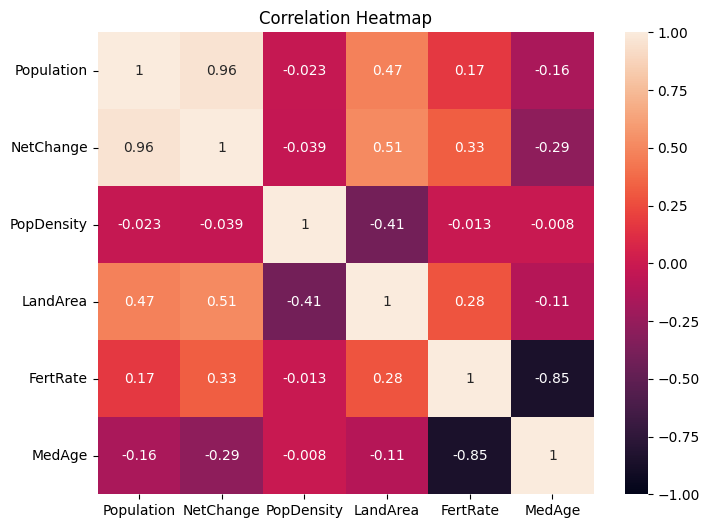

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap='rocket',
            vmin=-1, vmax=1)

plt.title('Correlation Heatmap')

plt.show()